# Staggered-grid (WRF) NetCDF files

WRF model output with mass and staggered (`*_stag`) dimensions and string bookkeeping variables. Inspection, plotting, retrieval, and variable mutation; affine polygon crop does not apply.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile

import numpy as np
import geopandas as gpd
from shapely.geometry import box

from pyramids.netcdf import NetCDF, UgridDataset
from pyramids.feature import FeatureCollection

DATA = Path('../../../../examples/data/netcdf/samples')

2026-06-17 23:41:19 | INFO | pyramids.base.config | Logging is configured.


## `none__17v__1d1-2d5-3d6-4d5__stag-str.nc`

WRF surface/3-D fields on mass and staggered grids (T2 = 2 m temperature).

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'none__17v__1d1-2d5-3d6-4d5__stag-str.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\none__17v__1d1-2d5-3d6-4d5__stag-str.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (9):
    Time                 size=3
    bottom_top           size=27
    bottom_top_stag      size=28
    ext_scalar           size=1
    soil_layers_stag     size=5
    south_north          size=60
    south_north_stag     size=61
    west_east            size=73
    west_east_stag       size=74
  Variables (17):
    ITIMESTEP dims=('/Time', '/ext_scalar') shape=(3, 1) dtype=int32
    IVGTYP dims=('/Time', '/south_north', '/west_east') shape=(3, 60, 73) dtype=int32
    MAPFAC_U dims=('/Time', '/south_north', '/west_east_stag') shape=(3, 60, 74) dtype=float32
    MAPFAC_V dims=('/Time', '/south_north_stag', '/west_east') shape=(3, 61, 73) dtype=float32
    P_TOP dims=('/Time', '/ext_scalar') shape=(3, 1) dtype=float32 unit='Pa'
    SMOIS dims=('/Time', '/soil_layers_stag', '/south_north', '/west_east') shape=(3, 5, 60, 73) dtype=float32 unit='m3 m-3'
    T dims=('/Time', '/bottom_top', '/south_north', '/west_east') shape=(3,

**Global attributes**

In [4]:
nc.global_attributes

{'BL_PBL_PHYSICS': 1,
 'BOTTOM-TOP_GRID_DIMENSION': 28,
 'BOTTOM-TOP_PATCH_END_STAG': 28,
 'BOTTOM-TOP_PATCH_END_UNSTAG': 27,
 'BOTTOM-TOP_PATCH_START_STAG': 1,
 'BOTTOM-TOP_PATCH_START_UNSTAG': 1,
 'CEN_LAT': 34.83157730102539,
 'CEN_LON': -81.02755737304688,
 'CU_PHYSICS': 1,
 'DAMP_OPT': 0,
 'DIFF_OPT': 0,
 'DT': 180.0,
 'DX': 30000.0,
 'DY': 30000.0,
 'DYN_OPT': 2,
 'GMT': 12.0,
 'GRIDTYPE': 'C',
 'ISICE': 24,
 'ISOILWATER': 14,
 'ISURBAN': 1,
 'ISWATER': 16,
 'JULDAY': 24,
 'JULYR': 2000,
 'KHDIF': 0.0,
 'KM_OPT': 1,
 'KVDIF': 0.0,
 'MAP_PROJ': 1,
 'MMINLU': 'USGS',
 'MOAD_CEN_LAT': 34.83157730102539,
 'MP_PHYSICS': 3,
 'RA_LW_PHYSICS': 1,
 'RA_SW_PHYSICS': 1,
 'SF_SFCLAY_PHYSICS': 1,
 'SF_SURFACE_PHYSICS': 1,
 'SOUTH-NORTH_GRID_DIMENSION': 61,
 'SOUTH-NORTH_PATCH_END_STAG': 61,
 'SOUTH-NORTH_PATCH_END_UNSTAG': 60,
 'SOUTH-NORTH_PATCH_START_STAG': 1,
 'SOUTH-NORTH_PATCH_START_UNSTAG': 1,
 'STAND_LON': -98.0,
 'START_DATE': '2000-01-24_12:00:00',
 'TITLE': ' OUTPUT FROM WRF V2.0 MO

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

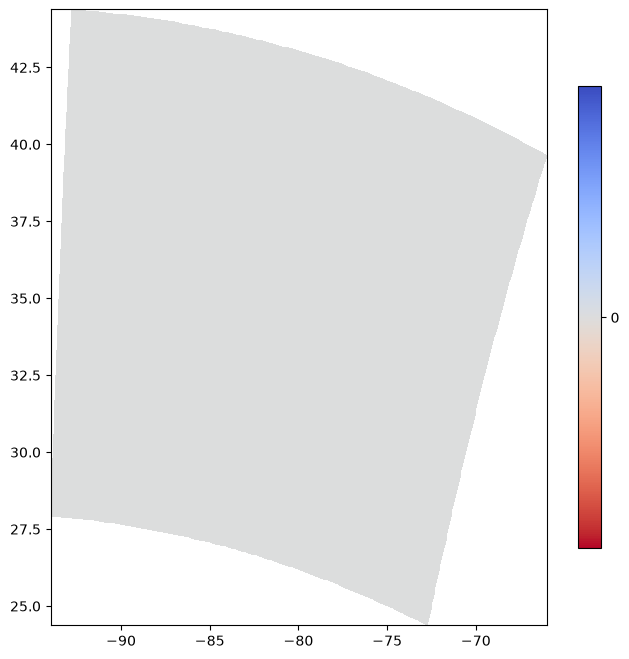

In [5]:
nc.plot(variable='T2')

**Retrieve the underlying data**

In [6]:
var = nc.get_variable('T2')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (3, 60, 73)
min / mean / max: 0.0 185.22796630859375 297.0773620605469


**Add a variable** — derive a 2-D field and append it as a new variable

In [7]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=(0.0, 1.0, 0.0, 0.0, 0.0, -1.0), epsg=var.epsg or 4326,
    variable_name='T2_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'T2_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['ITIMESTEP', 'IVGTYP', 'MAPFAC_U', 'MAPFAC_V', 'P_TOP', 'SMOIS', 'T', 'T2', 'T2_slice0', 'Times', 'U', 'V', 'W', 'XLAT', 'XLONG', 'ZNU', 'ZNW', 'ZS']


**Remove a variable**

In [8]:
nc.remove_variable('T2_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['ITIMESTEP', 'IVGTYP', 'MAPFAC_U', 'MAPFAC_V', 'P_TOP', 'SMOIS', 'T', 'T2', 'Times', 'U', 'V', 'W', 'XLAT', 'XLONG', 'ZNU', 'ZNW', 'ZS']


> **Note** — this grid is curvilinear/staggered (2-D coordinates / no single affine transform), so a polygon `crop` does not apply. The notebook focuses on inspection, plotting, retrieval, and variable mutation.

**Save the container to a new NetCDF file**

In [9]:
out = work / 'saved.nc'
nc.to_file(str(out))
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True
